## Parallelization

#### What is Parallelization in Langgraph?

In Langgraph nodes typically execute in a sequence defined by the edges, but when task does NOT depend on each other's output, you can run them in parallel. This is achieved by:

- Defining multiple nodes that can operate independantly
- Connecting them to a common starting point (e.g. START or another node)
- Merging their outputs into a downstream node if needed

Key benefits:

- **Speed** - Reduces total execution time by running tasks concurently
- **Scalability** - Handles larger workflows efficiently
- **Modularity** - Keeps the graph structure clean and reusable


Key takeaways:

- **When to paralellize** - Use it for independent tasks (e.g. generating multiple outputs, checking separate inputs)
- **Merging** - Downstream nodes can aggregate parallel results
- **Langgraph support** - The framework naturally supports this by waiting for all required inputs before preceeding

In [1]:
import os
from dotenv import load_dotenv

ENV_PATH = '../.env'
assert os.path.exists(ENV_PATH)

load_dotenv('../.env')

GROQ_API_KEY = os.environ['GROQ_API_KEY']
assert GROQ_API_KEY
print(f'----> GROQ_API_KEY: {GROQ_API_KEY[:3]}***{GROQ_API_KEY[-3:]}')


LANGCHAIN_API_KEY = os.environ['LANGCHAIN_API_KEY']
assert LANGCHAIN_API_KEY
print(f'----> LANGCHAIN_API_KEY: {LANGCHAIN_API_KEY[:3]}***{LANGCHAIN_API_KEY[-3:]}')

# Required by LangChain 
os.environ['LANGCHAIN_TRACING_V2'] = 'true'
LANGCHAIN_PROJECT = 'Parallelization example'
os.environ['LANGCHAIN_PROJECT'] = LANGCHAIN_PROJECT
print(f'---->LANGCHAIN_PROJECT: {LANGCHAIN_PROJECT}')

----> GROQ_API_KEY: gsk***qNU
----> LANGCHAIN_API_KEY: lsv***43b
---->LANGCHAIN_PROJECT: Parallelization example


In [3]:
from langchain_groq import ChatGroq

#LLM temperature is a parameter that controls the randomness and creativity of a large language model's output by adjusting the probability distribution of next-word predictions. Lower temperatures (e.g., <0.5) make the output more predictable and deterministic, favoring more common, "safer" words, which is good for factual accuracy. Higher temperatures (e.g., >0.8) increase randomness, leading to more varied, creative, and surprising outputs, ideal for tasks like brainstorming or storytelling. 
llm = ChatGroq(model='qwen/qwen3-32b', temperature=0, reasoning_format='hidden')
llm

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x111946e40>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x111947a10>, model_name='qwen/qwen3-32b', temperature=1e-08, reasoning_format='hidden', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [2]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

class State(TypedDict):
    topic: str
    characters: str
    settings: str
    premises: str
    story_intro: str

In [4]:
def generate_character(state: State) -> State:
    """Generate characters description"""
    input_prompt = f'Create two characters names and brief traits for a story about {state["topic"]}'
    msg = llm.invoke(input=input_prompt)
    return { "characters": msg.content }

def generate_settings(state: State) -> State:
    """Generate a story setting"""
    input_prompt = f'Describe a vivid setting for a story about {state["topic"]}'
    msg = llm.invoke(input=input_prompt)
    return { "settings": msg.content }

def generate_premise(state: State) -> State:
    """Generate a story premise"""
    input_prompt = f'Write a one-sentence plot premise for a story about {state["topic"]}'
    msg = llm.invoke(input=input_prompt)
    return { "premises": msg.content }

def combine(state: State) -> State:
    """Combine characters, setting and premise and create an intro"""
    prompt = f"""
    Write a short story introduction using these elements:\n
    Characters: {state['characters']}\n
    Settings: {state['settings']}\n
    Premises: {state['premises']}\n
    """
    msg = llm.invoke(input=prompt)
    return { 'story_intro': msg.content }

#### Create the graph

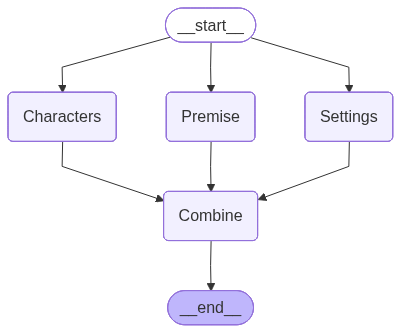

In [5]:
from IPython.display import display, Image

graph_builder = StateGraph(State)

# Add nodes
graph_builder.add_node('Characters', generate_character)
graph_builder.add_node('Premise', generate_premise)
graph_builder.add_node('Settings', generate_settings)
graph_builder.add_node('Combine', combine)

# Add edges
graph_builder.add_edge(START, "Characters")
graph_builder.add_edge(START, "Premise")
graph_builder.add_edge(START, "Settings")

graph_builder.add_edge("Characters", 'Combine')
graph_builder.add_edge("Premise", 'Combine')
graph_builder.add_edge("Settings", 'Combine')
graph_builder.add_edge('Combine', END)

graph = graph_builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [6]:
state: State = {'topic': 'Space exploration'}
response = graph.invoke(state)
response

{'topic': 'Space exploration',
 'characters': '**Character 1: Kael Veyra**  \n- **Role:** Impulsive and resourceful starship pilot with a knack for improvisation.  \n- **Traits:** A former smuggler turned explorer, Kael thrives on adrenaline and thrusters. Charismatic but reckless, they hide a deep-seated fear of failure beneath their bravado. Their left arm is scarred from a near-fatal engine malfunction, a reminder of past hubris.  \n- **Motivation:** Seeks redemption for a past betrayal while chasing the thrill of the unknown.  \n\n**Character 2: Dr. Lira Solen**  \n- **Role:** A meticulous astrobiologist specializing in exoplanetary ecosystems.  \n- **Traits:** Analytical and introverted, Lira is driven by curiosity and a need for precision. She carries a holographic journal to document every discovery, often to the annoyance of her crewmates. Haunted by the death of her mentor during a failed Mars colony, she’s determined to prove humanity’s place in the cosmos—scientifically, not

graph_builder = 